# GPU YouTube corpus - main analysis notebook (EDA + later sentiment)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

np.random.seed(42)
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 160)


## Paths and configuration

In [21]:
from pathlib import Path

ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent]
ROOT = None
for cand in ROOT_CANDIDATES:
    if (cand / "data-processed").exists() or (cand / "data-clean").exists():
        ROOT = cand
        break
if ROOT is None:
    ROOT = Path.cwd()

DATA_PROCESSED_DEFAULT = ROOT / "data-processed"
FALLBACK_DATA_DIR = ROOT / "data-clean"

DATA_PROCESSED = DATA_PROCESSED_DEFAULT if DATA_PROCESSED_DEFAULT.exists() else FALLBACK_DATA_DIR
FIG_DIR = ROOT / "figures"

comments_parquet = DATA_PROCESSED / "comments.parquet"
transcripts_parquet = DATA_PROCESSED / "transcripts.parquet"
videos_parquet = DATA_PROCESSED / "videos.parquet"
corpus_parquet = DATA_PROCESSED / "corpus.parquet"

print(f"Using data directory: {DATA_PROCESSED.resolve()}")
print(f"Figures will be saved to: {FIG_DIR.resolve()}")


Using data directory: C:\PythonProjects\DataStory-GPUs\data-clean
Figures will be saved to: C:\PythonProjects\DataStory-GPUs\figures


## Load data

In [22]:
def load_data():
    """Read all core parquet tables."""
    comments = pd.read_parquet(comments_parquet)
    transcripts = pd.read_parquet(transcripts_parquet)
    videos = pd.read_parquet(videos_parquet)
    corpus = pd.read_parquet(corpus_parquet)
    return comments, transcripts, videos, corpus


In [23]:
comments_df, transcripts_df, videos_df, corpus_df = load_data()
data_frames = {
    "comments": comments_df,
    "transcripts": transcripts_df,
    "videos": videos_df,
    "corpus": corpus_df,
}

summary_stats = {
    "video_count": len(videos_df),
    "total_comments": len(comments_df),
    "total_transcript_segments": len(transcripts_df),
}


## Basic info

In [24]:
def unique_video_ids(df):
    return df['video_id'].nunique() if 'video_id' in df.columns else np.nan

for name, df in data_frames.items():
    vid_count = unique_video_ids(df)
    print(f"{name}: shape={df.shape}, distinct video_id={vid_count}")


comments: shape=(762642, 9), distinct video_id=330
transcripts: shape=(307694, 6), distinct video_id=325
videos: shape=(330, 32), distinct video_id=330
corpus: shape=(1070336, 13), distinct video_id=330


## Basic sanity checks

In [25]:
def empty_text_stats(df, name):
    if 'text' not in df.columns:
        print(f"{name}: no text column to check.")
        return
    text_series = df['text'].fillna("").astype(str)
    empty_mask = text_series.str.strip().eq("")
    count = int(empty_mask.sum())
    pct = (count / len(df) * 100) if len(df) else 0
    print(f"{name}: empty/whitespace text = {count} rows ({pct:.2f}%)")

empty_text_stats(comments_df, "comments_df")
empty_text_stats(corpus_df, "corpus_df")

if {'video_id', 'comment_id'}.issubset(comments_df.columns):
    dup_pairs = int(comments_df.duplicated(subset=['video_id', 'comment_id']).sum())
else:
    dup_pairs = 0
dup_text = int(comments_df.duplicated(subset=['video_id', 'text']).sum())
print(f"comments_df: duplicate (video_id, comment_id) pairs = {dup_pairs}")
print(f"comments_df: duplicate (video_id, text) pairs = {dup_text}")


comments_df: empty/whitespace text = 0 rows (0.00%)
corpus_df: empty/whitespace text = 0 rows (0.00%)
comments_df: duplicate (video_id, comment_id) pairs = 0
comments_df: duplicate (video_id, text) pairs = 6070


In [26]:
def preview_df(df, name, head_n=5):
    print(f"--- {name} ---")
    display(df.head(head_n))
    print(df.dtypes)
    print()

for name, df in data_frames.items():
    preview_df(df, name)


--- comments ---


,video_id,comment_id,parent_id,author,text,like_count,published_at,is_reply,raw_path
0,-LAH5vh-Cpg,UgwLD6mOcKzW7uydecl4AaABAg,None,@wizzardrincewind9458,👍🖖,NaN,NaT,False,data-raw\comments\-LAH5vh-Cpg.comments.json
1,-LAH5vh-Cpg,UgwOpxeGdV-UzJh24S54AaABAg,None,@one2manyhobbies956,After having my 9060xt 16gb I'm very happy wit...,NaN,NaT,False,data-raw\comments\-LAH5vh-Cpg.comments.json
2,-LAH5vh-Cpg,Ugw-asbj9qmOkM1UUdd4AaABAg,None,@WillFuI,For the cost per frame don’t u want lower is b...,NaN,NaT,False,data-raw\comments\-LAH5vh-Cpg.comments.json
3,-LAH5vh-Cpg,UgyQs9cIWFH49EYU1yZ4AaABAg,None,@xitachi_da_goatx9975,I just got my 9060xt after going back and fort...,NaN,NaT,False,data-raw\comments\-LAH5vh-Cpg.comments.json
4,-LAH5vh-Cpg,UgzMh9kuWmIgR6gUeCt4AaABAg,None,@srobeck77,"If you bought the 8gb version in 2025, slap yo...",NaN,NaT,False,data-raw\comments\-LAH5vh-Cpg.comments.json


video_id                     object
comment_id                   object
parent_id                    object
author                       object
text                         object
like_count                  float64
published_at    datetime64[ns, UTC]
is_reply                       bool
raw_path                     object
dtype: object

--- transcripts ---


,video_id,lang,start_seconds,end_seconds,text,raw_path
0,-LAH5vh-Cpg,en,5.0,5.0,[Music],data-raw\transcripts\-LAH5vh-Cpg.en.vtt
1,-LAH5vh-Cpg,en,5.0,8.0,[Music]\nToday we're reviewing AMD's new Radeon,data-raw\transcripts\-LAH5vh-Cpg.en.vtt
2,-LAH5vh-Cpg,en,8.0,8.0,Today we're reviewing AMD's new Radeon,data-raw\transcripts\-LAH5vh-Cpg.en.vtt
3,-LAH5vh-Cpg,en,8.0,13.0,Today we're reviewing AMD's new Radeon\nRX 960...,data-raw\transcripts\-LAH5vh-Cpg.en.vtt
4,-LAH5vh-Cpg,en,13.0,13.0,RX 960 XT which is available in 8 and 16,data-raw\transcripts\-LAH5vh-Cpg.en.vtt


video_id          object
lang              object
start_seconds    float64
end_seconds      float64
text              object
raw_path          object
dtype: object

--- videos ---


,video_id,title,uploader,channel,channel_id,duration,view_count,like_count,comment_count,categories,tags,available_captions,upload_date,webpage_url,info_path,timestamp,manifest_video_id,manifest_url,manifest_gpu_model,manifest_brand,manifest_video_title,manifest_status_comments,manifest_status_transcripts,manifest_comments_path,manifest_transcripts_dir,manifest_info_path,manifest_error_message,manifest_started_at,manifest_finished_at,manifest_elapsed_sec,manifest_num_transcript_files,release_timestamp
0,-LAH5vh-Cpg,"AMD Radeon RX 9060 XT 16GB Review, Gaming Benc...",Hardware Unboxed,Hardware Unboxed,UCI8iQa1hv7oV_Z8D35vVuSg,1371,336623,13277,1714,Science & Technology,hardware unboxed,None,2025-06-04 00:00:00+00:00,https://www.youtube.com/watch?v=-LAH5vh-Cpg,data-raw\info\-LAH5vh-Cpg.info.json,2025-06-04 13:00:01+00:00,-LAH5vh-Cpg,https://www.youtube.com/watch?v=-LAH5vh-Cpg,Radeon RX 9060 XT,AMD,"AMD Radeon RX 9060 XT 16GB Review, Gaming Benc...",ok,ok,C:\PythonProjects\DataStory-GPUs\data-raw\comm...,C:\PythonProjects\DataStory-GPUs\data-raw\tran...,C:\PythonProjects\DataStory-GPUs\data-raw\info...,,2025-11-04 18:55:46.829820+00:00,2025-11-04 18:55:46.838021+00:00,0.01,1,NaT
1,-Lcyyl2kQL8,AMD RX 5600 XT Review – Gaming & Overclocking,optimum,optimum,UCRYOj4DmyxhBVrdvbsUwmAA,571,108206,2572,185,Science & Technology,"AMD,RX 5600 XT,Review,Benchmarks,Test,gaming,p...",None,2020-01-21 00:00:00+00:00,https://www.youtube.com/watch?v=-Lcyyl2kQL8,data-raw\info\-Lcyyl2kQL8.info.json,2020-01-21 14:00:50+00:00,-Lcyyl2kQL8,https://www.youtube.com/watch?v=-Lcyyl2kQL8,Radeon RX 5600 XT,AMD,AMD RX 5600 XT Review – Gaming & Overclocking,ok,ok,C:\PythonProjects\DataStory-GPUs\data-raw\comm...,C:\PythonProjects\DataStory-GPUs\data-raw\tran...,C:\PythonProjects\DataStory-GPUs\data-raw\info...,,2025-11-04 18:53:24.089112+00:00,2025-11-04 18:53:24.091453+00:00,0.00,1,NaT
2,-M1bMzVzZF0,The Intel Arc B580: Midrange GPU Magic!,Level1Techs,Level1Techs,UC4w1YQAJMWOz4qtxinq55LQ,1691,131977,5728,739,Science & Technology,"technology,science,design,ux,computers,hardwar...",None,2024-12-12 00:00:00+00:00,https://www.youtube.com/watch?v=-M1bMzVzZF0,data-raw\info\-M1bMzVzZF0.info.json,2024-12-12 14:08:28+00:00,-M1bMzVzZF0,https://www.youtube.com/watch?v=-M1bMzVzZF0,Arc A580,INTEL,The Intel Arc B580: Midrange GPU Magic!,ok,ok,C:\PythonProjects\DataStory-GPUs\data-raw\comm...,C:\PythonProjects\DataStory-GPUs\data-raw\tran...,C:\PythonProjects\DataStory-GPUs\data-raw\info...,,2025-11-04 18:57:03.334429+00:00,2025-11-04 18:57:03.338115+00:00,0.00,1,NaT
3,-PtTUnj4od4,AMD 6900XT... Something isn’t right...,JayzTwoCents,JayzTwoCents,UCkWQ0gDrqOCarmUKmppD7GQ,1160,923401,38391,5170,Science & Technology,"amd,big navi,is big navi worth it,is big navi ...",None,2020-12-08 00:00:00+00:00,https://www.youtube.com/watch?v=-PtTUnj4od4,data-raw\info\-PtTUnj4od4.info.json,2020-12-08 14:00:01+00:00,-PtTUnj4od4,https://www.youtube.com/watch?v=-PtTUnj4od4,Radeon RX 6900 XT,AMD,AMD 6900XT... Something isn’t right…,ok,ok,C:\PythonProjects\DataStory-GPUs\data-raw\comm...,C:\PythonProjects\DataStory-GPUs\data-raw\tran...,C:\PythonProjects\DataStory-GPUs\data-raw\info...,,2025-11-04 18:54:24.530558+00:00,2025-11-04 18:54:24.555183+00:00,0.02,1,NaT
4,-SAWtKEIYbw,"AMD Radeon RX 5700 XT Review: Thermals, Noise,...",Gamers Nexus,Gamers Nexus,UChIs72whgZI9w6d6FhwGGHA,1794,453926,11178,2145,Gaming,"gamersnexus,gamers nexus,computer hardware,amd...",None,2019-07-07 00:00:00+00:00,https://www.youtube.com/watch?v=-SAWtKEIYbw,data-raw\info\-SAWtKEIYbw.info.json,2019-07-07 16:30:00+00:00,-SAWtKEIYbw,https://www.youtube.com/watch?v=-SAWtKEIYbw,Radeon RX 5700 XT,AMD,"AMD Radeon RX 5700 XT Review: Thermals, Noise,...",ok,ok,C:\PythonProjects\DataStory-GPUs\data-raw\comm...,C:\PythonProjects\DataStory-GPUs\data-raw\tran...,C:\PythonProjects\DataStory-GPUs\data-raw\info...,,2025-11-04 18:53:42.337517+00:00,2025-11-04 18:53:42.346630+00:00,0.01,1,NaT


video_id                                      object
title                                         object
uploader                                      object
channel                                       object
channel_id                                    object
                                        ...         
manifest_started_at              datetime64[ns, UTC]
manifest_finished_at             datetime64[ns, UTC]
manifest_elapsed_sec                         float64
manifest_num_transcript_files                  int64
release_timestamp                datetime64[ns, UTC]
Length: 32, dtype: object

--- corpus ---


,video_id,text,timestamp,source_type,comment_id,parent_id,author,like_count,is_reply,raw_path,lang,start_seconds,end_seconds
0,-LAH5vh-Cpg,👍🖖,NaT,comment,UgwLD6mOcKzW7uydecl4AaABAg,None,@wizzardrincewind9458,NaN,False,data-raw\comments\-LAH5vh-Cpg.comments.json,None,NaN,NaN
1,-LAH5vh-Cpg,After having my 9060xt 16gb I'm very happy wit...,NaT,comment,UgwOpxeGdV-UzJh24S54AaABAg,None,@one2manyhobbies956,NaN,False,data-raw\comments\-LAH5vh-Cpg.comments.json,None,NaN,NaN
2,-LAH5vh-Cpg,For the cost per frame don’t u want lower is b...,NaT,comment,Ugw-asbj9qmOkM1UUdd4AaABAg,None,@WillFuI,NaN,False,data-raw\comments\-LAH5vh-Cpg.comments.json,None,NaN,NaN
3,-LAH5vh-Cpg,I just got my 9060xt after going back and fort...,NaT,comment,UgyQs9cIWFH49EYU1yZ4AaABAg,None,@xitachi_da_goatx9975,NaN,False,data-raw\comments\-LAH5vh-Cpg.comments.json,None,NaN,NaN
4,-LAH5vh-Cpg,"If you bought the 8gb version in 2025, slap yo...",NaT,comment,UgzMh9kuWmIgR6gUeCt4AaABAg,None,@srobeck77,NaN,False,data-raw\comments\-LAH5vh-Cpg.comments.json,None,NaN,NaN


video_id                      object
text                          object
timestamp        datetime64[ns, UTC]
source_type                   object
comment_id                    object
parent_id                     object
author                        object
like_count                   float64
is_reply                      object
raw_path                      object
lang                          object
start_seconds                float64
end_seconds                  float64
dtype: object



## Scale descriptive stats

In [27]:
# Video durations
video_duration_col = 'duration_sec' if 'duration_sec' in videos_df.columns else 'duration'
total_video_seconds = videos_df[video_duration_col].fillna(0).astype(float).sum()
total_video_hours = total_video_seconds / 3600
summary_stats['total_video_hours'] = total_video_hours

# Transcript durations
if 'duration_sec' in transcripts_df.columns:
    transcript_duration = transcripts_df['duration_sec'].fillna(0)
else:
    transcript_duration = (transcripts_df['end_seconds'].fillna(0) - transcripts_df['start_seconds'].fillna(0)).clip(lower=0)
transcript_hours = transcript_duration.sum() / 3600
summary_stats['caption_hours'] = transcript_hours

# Corpus word counts
def approx_word_count(series):
    return int(series.fillna("").str.strip().str.split().str.len().sum())

total_corpus_words = approx_word_count(corpus_df['text'])
comment_words = approx_word_count(corpus_df.loc[corpus_df['source_type'] == 'comment', 'text'])
transcript_words = approx_word_count(corpus_df.loc[corpus_df['source_type'] == 'transcript', 'text'])
WAR_AND_PEACE_WORDS = 600_000
war_peace_multiple = total_corpus_words / WAR_AND_PEACE_WORDS if WAR_AND_PEACE_WORDS else np.nan

summary_stats.update({
    'total_corpus_words': total_corpus_words,
    'comment_words': comment_words,
    'transcript_words': transcript_words,
    'war_peace_multiple': war_peace_multiple,
})

print(f"Total video hours (approx): {total_video_hours:,.2f}h")
print(f"Caption hours (transcripts): {transcript_hours:,.2f}h")
print(f"Total corpus words: {total_corpus_words:,}")
print(f"Comment words: {comment_words:,}; Transcript words: {transcript_words:,}")
print(f"Corpus vs War and Peace (600k words): {war_peace_multiple:,.2f}x")

# Comment volume and engagement
total_comments = len(comments_df)
comments_per_video = comments_df.groupby('video_id').size().rename('comment_count')
comments_per_video_mean = comments_per_video.mean()
comments_per_video_median = comments_per_video.median()
summary_stats['comments_per_video_mean'] = comments_per_video_mean
summary_stats['comments_per_video_median'] = comments_per_video_median

view_counts = videos_df[['video_id', 'view_count']].dropna()
view_counts = view_counts[view_counts['view_count'] > 0]
merged_comments_views = comments_per_video.to_frame().join(view_counts.set_index('video_id'), how='inner')
merged_comments_views['comments_per_1k_views'] = merged_comments_views['comment_count'] / (merged_comments_views['view_count'] / 1000)
comments_per_1k_mean = merged_comments_views['comments_per_1k_views'].mean()
comments_per_1k_median = merged_comments_views['comments_per_1k_views'].median()

summary_stats.update({
    'total_comments': total_comments,
    'comments_per_1k_views_mean': comments_per_1k_mean,
    'comments_per_1k_views_median': comments_per_1k_median,
})

print(f"Total comments: {total_comments:,}")
print(f"Comments per video - mean: {comments_per_video_mean:,.2f}, median: {comments_per_video_median:,.2f}")
print(f"Comments per 1k views - mean: {comments_per_1k_mean:,.2f}, median: {comments_per_1k_median:,.2f}")


Total video hours (approx): 101.36h
Caption hours (transcripts): 101.77h
Total corpus words: 23,640,046
Comment words: 20,420,835; Transcript words: 3,219,211
Corpus vs War and Peace (600k words): 39.40x
Total comments: 762,642
Comments per video - mean: 2,311.04, median: 1,459.00
Comments per 1k views - mean: 5.11, median: 4.49


## Coverage and quick distributions (no plots)

In [28]:
# Transcript coverage
videos_with_transcripts = transcripts_df['video_id'].nunique() if 'video_id' in transcripts_df.columns else 0
total_videos = len(videos_df)
videos_without_transcripts = max(total_videos - videos_with_transcripts, 0)
coverage_pct = (videos_with_transcripts / total_videos * 100) if total_videos else 0
zero_segments_pct = (videos_without_transcripts / total_videos * 100) if total_videos else 0
summary_stats['transcript_coverage_pct'] = coverage_pct

print(f"Videos with transcripts: {videos_with_transcripts} / {total_videos} ({coverage_pct:.2f}%)")
print(f"Videos with zero transcript segments: {videos_without_transcripts} / {total_videos} ({zero_segments_pct:.2f}%)")

# Language distribution
lang_counts = transcripts_df['lang'].value_counts().head(10) if 'lang' in transcripts_df.columns else pd.Series(dtype=int)
summary_stats['top_langs'] = lang_counts
print("Top transcript languages (top 10):")
print(lang_counts)

# Length summaries
comment_chars = comments_df['text'].fillna("").str.len()
comment_words_len = comments_df['text'].fillna("").str.split().str.len()

def describe_series(series):
    return {
        'mean': series.mean(),
        'median': series.median(),
        'p95': series.quantile(0.95),
    }

comment_char_desc = describe_series(comment_chars)
comment_word_desc = describe_series(comment_words_len)

transcript_duration = transcript_duration if 'transcript_duration' in globals() else (transcripts_df['end_seconds'].fillna(0) - transcripts_df['start_seconds'].fillna(0)).clip(lower=0)
transcript_duration_desc = describe_series(transcript_duration)

print("Comment length (chars):", comment_char_desc)
print("Comment length (words):", comment_word_desc)
print("Transcript segment duration (sec):", transcript_duration_desc)


Videos with transcripts: 325 / 330 (98.48%)
Videos with zero transcript segments: 5 / 330 (1.52%)
Top transcript languages (top 10):
lang
en       303884
en-US      3810
Name: count, dtype: int64
Comment length (chars): {'mean': np.float64(142.8788028983455), 'median': 86.0, 'p95': np.float64(448.0)}
Comment length (words): {'mean': np.float64(26.77643638823983), 'median': 16.0, 'p95': np.float64(83.0)}
Transcript segment duration (sec): {'mean': np.float64(1.1907512008683951), 'median': 1.0, 'p95': np.float64(3.0)}


## Summary

In [29]:
war_and_peace_equiv = summary_stats.get('war_peace_multiple', np.nan)
top_langs = summary_stats.get('top_langs', pd.Series(dtype=int))
lang_summary = ", ".join([f"{lang} ({count})" for lang, count in top_langs.items()])

summary_lines = [
    f"Videos: {summary_stats.get('video_count', 0):,}",
    f"Total comments: {summary_stats.get('total_comments', 0):,}",
    f"Transcript segments: {summary_stats.get('total_transcript_segments', 0):,}",
    f"Video hours vs caption hours: {summary_stats.get('total_video_hours', 0):,.2f}h vs {summary_stats.get('caption_hours', 0):,.2f}h",
    f"Corpus words: {summary_stats.get('total_corpus_words', 0):,} (~{war_and_peace_equiv:,.2f}x War and Peace)",
    f"Comment vs transcript words: {summary_stats.get('comment_words', 0):,} / {summary_stats.get('transcript_words', 0):,}",
    f"Transcript coverage: {summary_stats.get('transcript_coverage_pct', 0):.2f}%",
    f"Main languages (top counts): {lang_summary}",
]

summary_md = "\n".join([f"- {line}" for line in summary_lines])
display(Markdown(summary_md))


- Videos: 330
- Total comments: 762,642
- Transcript segments: 307,694
- Video hours vs caption hours: 101.36h vs 101.77h
- Corpus words: 23,640,046 (~39.40x War and Peace)
- Comment vs transcript words: 20,420,835 / 3,219,211
- Transcript coverage: 98.48%
- Main languages (top counts): en (303884), en-US (3810)

## Stage 2 - Visual EDA and grouped statistics

In [30]:
import matplotlib.pyplot as plt
import numpy as np


def safe_month_floor(datetime_series):
    dt = pd.to_datetime(datetime_series, errors="coerce", utc=True)
    dt = dt.dt.tz_convert(None)
    return dt.dt.to_period("M").dt.to_timestamp()


def approx_word_count(series):
    return int(series.fillna("").str.strip().str.split().str.len().sum())


### Distributions - comments and transcripts

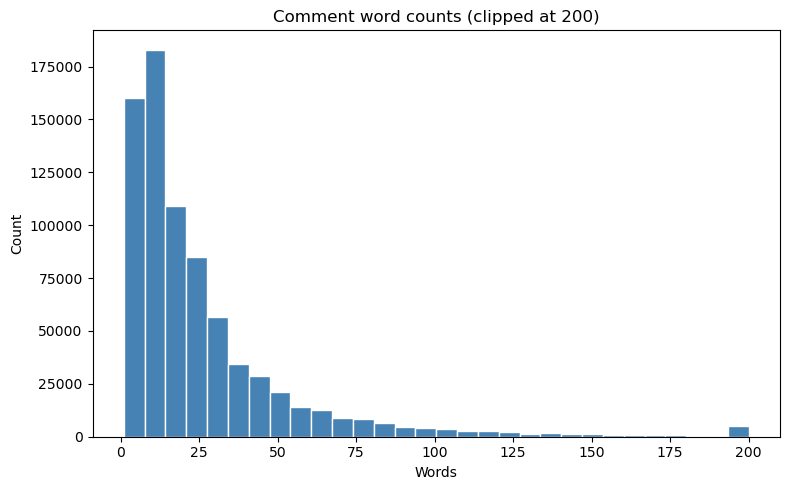

In [31]:
comment_text = comments_df['text'].fillna("")
comment_words = comment_text.str.split().str.len().clip(upper=200)
comment_chars = comment_text.str.len().clip(upper=2000)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(comment_words, bins=30, color="steelblue", edgecolor="white")
ax.set_title("Comment word counts (clipped at 200)")
ax.set_xlabel("Words")
ax.set_ylabel("Count")
fig.tight_layout()
fig.savefig(FIG_DIR / "comments_length_words_hist.png", dpi=150)
plt.show()

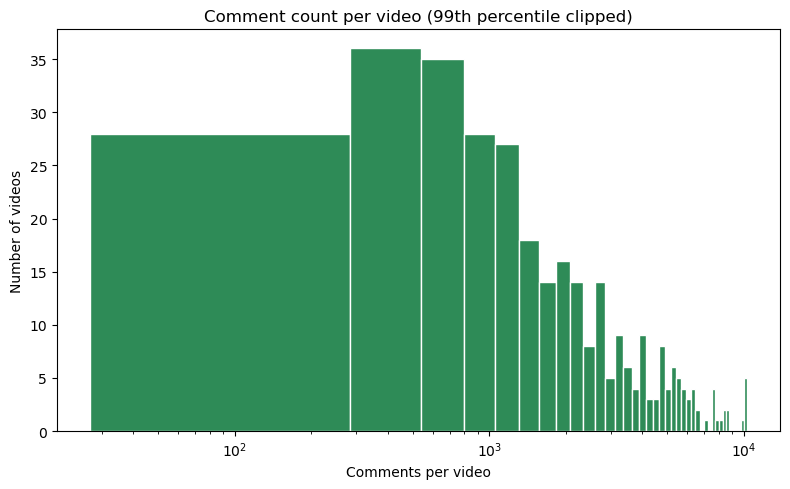

In [32]:
# Per-video comment volume
comments_per_video = comments_df.groupby('video_id').size().rename('comment_count')
comments_per_video_clipped = comments_per_video.clip(upper=comments_per_video.quantile(0.99))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(comments_per_video_clipped, bins=40, color='seagreen', edgecolor='white')
ax.set_title('Comment count per video (99th percentile clipped)')
ax.set_xlabel('Comments per video')
ax.set_ylabel('Number of videos')
ax.set_xscale('log')
fig.tight_layout()
fig.savefig(FIG_DIR / 'comments_per_video_hist.png', dpi=150)
plt.show()


### Time series: activity over time

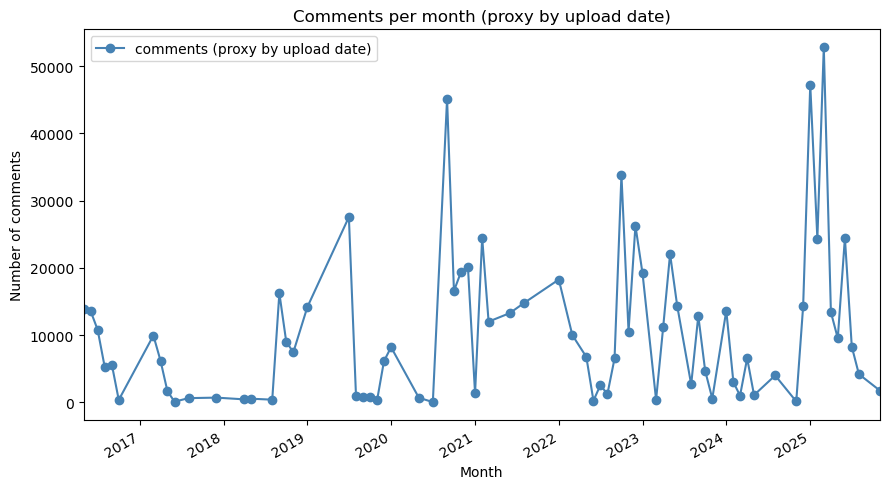

In [33]:
# Monthly comment activity using video upload date as proxy (comment timestamps unavailable)
# Each comment inherits its video's upload timestamp; months are floored to the first of the month.
video_ts_col = None
for cand in ['upload_date', 'publish_date_utc', 'release_timestamp', 'timestamp', 'timestamp_utc']:
    if cand in videos_df.columns:
        video_ts_col = cand
        break

if video_ts_col is None:
    print('No usable upload timestamp in videos_df; skipping monthly time series plots.')
else:
    comments_with_video = comments_df.merge(videos_df[['video_id', video_ts_col]], on='video_id', how='left')
    comments_with_video['month'] = safe_month_floor(comments_with_video[video_ts_col])
    monthly_comments = (comments_with_video
                        .dropna(subset=['month'])
                        .groupby('month')
                        .size()
                        .rename('num_comments')
                        .reset_index())
    monthly_comments = monthly_comments.sort_values('month')

    if monthly_comments.empty:
        print('No proxy month data available to plot.')
    else:
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(monthly_comments['month'], monthly_comments['num_comments'], marker='o', color='steelblue', label='comments (proxy by upload date)')
        ax.set_title('Comments per month (proxy by upload date)')
        ax.set_xlabel('Month')
        ax.set_ylabel('Number of comments')
        ax.legend()
        fig.autofmt_xdate()
        ax.set_xlim(monthly_comments['month'].min(), monthly_comments['month'].max())
        fig.tight_layout()
        fig.savefig(FIG_DIR / 'docs_per_month_by_source.png', dpi=150)
        plt.show()


### GPU model / brand breakdown

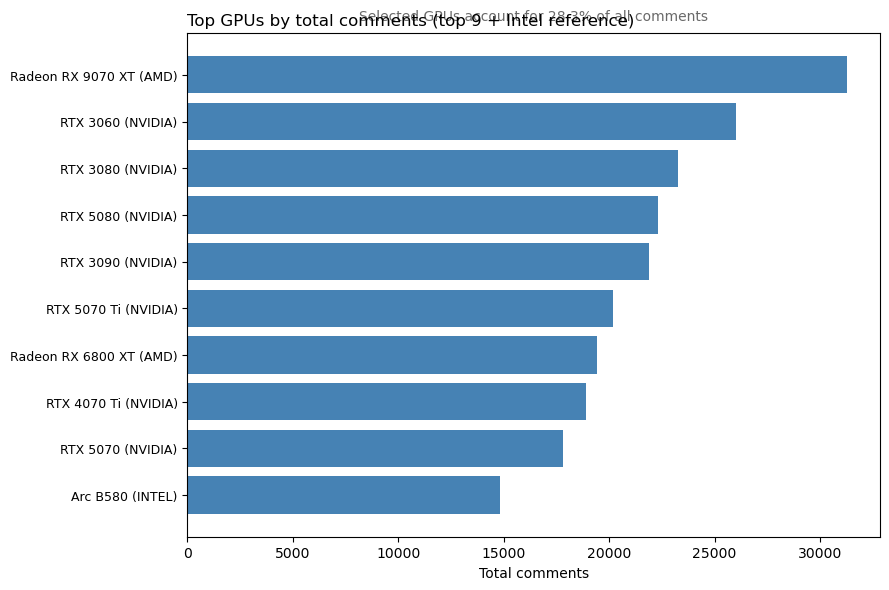

In [34]:
# Top GPU models by total comments (top 9 overall + top Intel placeholder if missing)
model_col = 'manifest_gpu_model' if 'manifest_gpu_model' in videos_df.columns else 'gpu_model'
brand_col = 'manifest_brand' if 'manifest_brand' in videos_df.columns else None

if model_col not in videos_df.columns:
    print('No GPU model column available; skipping top models chart.')
else:
    comment_counts_by_video = comments_df.groupby('video_id').size().rename('total_comments')
    model_df = videos_df[['video_id', model_col]].copy()
    if brand_col and brand_col in videos_df.columns:
        model_df['brand'] = videos_df[brand_col]
    else:
        model_df['brand'] = None

    model_df = model_df.join(comment_counts_by_video, on='video_id')
    model_df['total_comments'] = model_df['total_comments'].fillna(0)
    model_df = model_df.dropna(subset=[model_col])

    agg_models = (model_df
                  .groupby([model_col, 'brand'])
                  .agg(total_comments=('total_comments', 'sum'))
                  .reset_index())
    agg_models = agg_models.sort_values('total_comments', ascending=False)

    # Top 9 overall
    top9 = agg_models.head(9)

    # Top 1 Intel if present; otherwise add a placeholder zero row for contrast
    intel_filter = (agg_models['brand'].str.lower() == 'intel') if 'brand' in agg_models.columns else False
    intel_rows = agg_models[intel_filter]
    top_intel = None
    if not intel_rows.empty:
        top_intel = intel_rows.head(1)
    else:
        contains_intel = agg_models[agg_models[model_col].str.contains('Intel', case=False, na=False)]
        if not contains_intel.empty:
            top_intel = contains_intel.head(1)
    if top_intel is None or top_intel.empty:
        top_intel = pd.DataFrame([{model_col: 'Intel GPU (no data)', 'brand': 'Intel', 'total_comments': 0}])

    combined = pd.concat([top9, top_intel]).drop_duplicates(subset=[model_col, 'brand'], keep='first')
    combined = combined.sort_values('total_comments', ascending=True)  # for barh

    if combined.empty:
        print('No model comment data available for plotting.')
    else:
        total_all = agg_models['total_comments'].sum()
        combined_share = (combined['total_comments'].sum() / total_all * 100) if total_all else 0

        def make_label(row):
            brand = row['brand'] if pd.notna(row['brand']) and row['brand'] not in (None, '') else None
            return f"{row[model_col]} ({brand})" if brand else f"{row[model_col]}"

        combined['label'] = combined.apply(make_label, axis=1)

        fig, ax = plt.subplots(figsize=(9, 6))
        ax.barh(combined['label'], combined['total_comments'], color='steelblue')
        ax.set_title('Top GPUs by total comments (top 9 + Intel reference)', loc='left')
        ax.set_xlabel('Total comments')
        subtitle = f"Selected GPUs account for {combined_share:.1f}% of all comments"
        ax.text(0.5, 1.02, subtitle, transform=ax.transAxes, ha='center', va='bottom', fontsize=10, color='dimgray')
        ax.tick_params(axis='y', labelsize=9)
        fig.tight_layout()
        fig.savefig(FIG_DIR / 'top_gpu_models_comments_bar.png', dpi=150)
        plt.show()


### Time-series notes (proxy by upload date)

- Months are derived from video upload dates and applied to comments as a proxy (comment timestamps missing).
- Single-line plot shows comment volume per month; peaks correspond to upload-heavy months.
- Generational/group breakdown shows which GPU lines attract the most comments (see bar chart).

### Stage 2 summary (run previous cells first)

### Comments by GPU generation

No generation column found; using GPU model as grouping for this chart.


,group,gen_total_comments,gen_num_videos,gen_comments_per_video
66,Radeon RX 9070 XT,31276,10,3127.600000
19,RTX 3060,26001,5,5200.200000
23,RTX 3080,23260,5,4652.000000
41,RTX 5080,22334,5,4466.800000
25,RTX 3090,21884,5,4376.800000
40,RTX 5070 Ti,20193,5,4038.600000
56,Radeon RX 6800 XT,19406,5,3881.200000
31,RTX 4070 Ti,18893,3,6297.666667
39,RTX 5070,17828,5,3565.600000
42,RTX 5090,17187,5,3437.400000


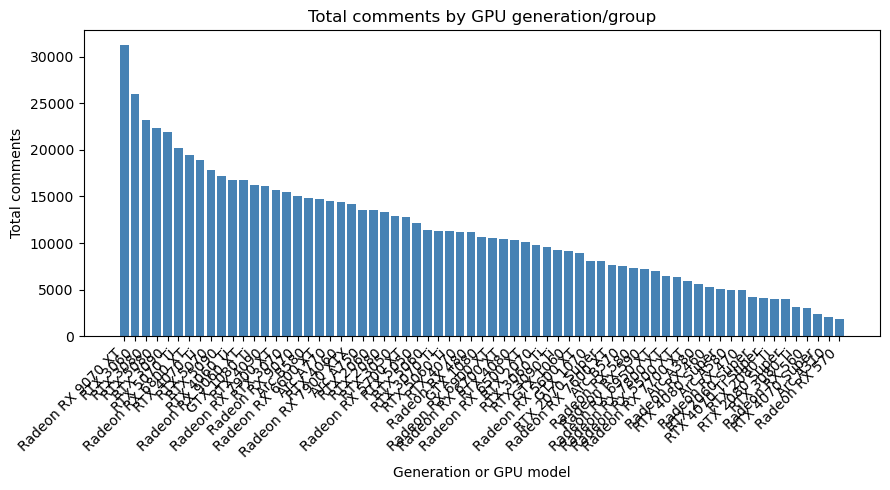

In [35]:
# Comments by GPU generation (or gpu_model if generation missing)
gen_col = None
for cand in ['gen', 'generation', 'gpu_generation']:
    if cand in videos_df.columns:
        gen_col = cand
        break

if gen_col is None:
    if 'manifest_gpu_model' in videos_df.columns:
        grouping_col = 'manifest_gpu_model'
    elif 'gpu_model' in videos_df.columns:
        grouping_col = 'gpu_model'
    else:
        grouping_col = None
    print('No generation column found; using GPU model as grouping for this chart.' if grouping_col else 'No generation or gpu_model column available; skipping generation chart.')
else:
    grouping_col = gen_col

if grouping_col is None:
    print('Skipping generation chart; no grouping column available.')
else:
    comment_counts_by_video = comments_df.groupby('video_id').size().rename('total_comments')
    videos_with_comments = videos_df[['video_id']].copy()
    videos_with_comments['group'] = videos_df[grouping_col]
    videos_with_comments = videos_with_comments.join(comment_counts_by_video, on='video_id')
    videos_with_comments['total_comments'] = videos_with_comments['total_comments'].fillna(0)

    if videos_with_comments['group'].isna().all():
        print('Grouping column is entirely missing; skipping generation chart.')
    else:
        agg_gen = (videos_with_comments.dropna(subset=['group'])
                   .groupby('group')
                   .agg(gen_total_comments=('total_comments', 'sum'),
                        gen_num_videos=('video_id', 'nunique'))
                   .reset_index())
        agg_gen['gen_comments_per_video'] = agg_gen.apply(lambda row: row['gen_total_comments'] / row['gen_num_videos'] if row['gen_num_videos'] > 0 else np.nan, axis=1)
        agg_gen = agg_gen.sort_values('gen_total_comments', ascending=False)

        display(agg_gen.head(10))

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.bar(agg_gen['group'], agg_gen['gen_total_comments'], color='steelblue')
        ax.set_title('Total comments by GPU generation/group')
        ax.set_xlabel('Generation or GPU model')
        ax.set_ylabel('Total comments')
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        fig.tight_layout()
        fig.savefig(FIG_DIR / 'comments_by_generation.png', dpi=150)
        plt.show()


In [37]:
# Auto-generated summary for Stage 2 findings
comment_words = comments_df['text'].fillna('').str.split().str.len()
segment_duration = segment_duration if 'segment_duration' in locals() else (transcripts_df['end_seconds'].fillna(0) - transcripts_df['start_seconds'].fillna(0)).clip(lower=0)
comment_len_median = float(comment_words.median())
comment_len_p95 = float(comment_words.quantile(0.95))
segment_median = float(segment_duration.median())
segment_p95 = float(segment_duration.quantile(0.95))

monthly_msg = "Comments per month (proxied by video upload date)" if 'monthly_comments' in locals() and not monthly_comments.empty else "No proxy month data to plot"

# GPU model summary
if 'top10_models' in locals() and not top10_models.empty:
    top_row = top10_models.iloc[0]
    top_models_brief = f"Top model by comments: {top_row['gpu_model']} ({top_row['brand']}), comments={int(top_row['total_comments'])}."
else:
    top_models_brief = "GPU models: aggregation computed; see tables/plots for leaders."

# Generation/group summary
if 'agg_gen' in locals() and not agg_gen.empty:
    top_gen = agg_gen.iloc[0]
    gen_brief = f"Top generation/group: {top_gen['group']} with {int(top_gen['gen_total_comments'])} comments." if 'group' in top_gen else "Generation/group summary available."
else:
    gen_brief = "Generation/group summary not available."

word_share = corpus_df.groupby('source_type')['text'].apply(approx_word_count).reset_index(name='total_words')
word_share = word_share.sort_values('total_words', ascending=False)
word_share_lines = ', '.join([f"{row.source_type}: {row.total_words:,}" for row in word_share.itertuples(index=False)])

summary_lines = [
    f"Comment lengths: median ~{comment_len_median:.0f} words; 95th pct ~{comment_len_p95:.0f} words.",
    f"Transcript segment durations: median ~{segment_median:.1f}s; 95th pct ~{segment_p95:.1f}s.",
    f"Time evolution: {monthly_msg}.",
    top_models_brief,
    gen_brief,
    f"Word share (comments vs transcripts): {word_share_lines}.",
]

summary_md = '\n'.join([f"- {line}" for line in summary_lines])
display(Markdown(summary_md))


- Comment lengths: median ~16 words; 95th pct ~83 words.
- Transcript segment durations: median ~1.0s; 95th pct ~3.0s.
- Time evolution: Comments per month (proxied by video upload date).
- GPU models: aggregation computed; see tables/plots for leaders.
- Top generation/group: Radeon RX 9070 XT with 31276 comments.
- Word share (comments vs transcripts): comment: 20,420,835, transcript: 3,219,211.